# Library

In [1]:
import sys, warnings
sys.path.append('..')
from src.preprocessing import full_preprocessing_pipeline
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import full_preprocessing_pipeline
from src.features import add_engineered_features

# Load Data

In [2]:
df = pd.read_csv('D:\Dibimbing.Id\Supply Chain\dataset\DataCoSupplyChainDataset.csv', encoding='latin1')
target = 'Late_delivery_risk'

# menambahkan fitur baru
df = add_engineered_features(df)  

# membaca data yang sudah melewati preprocessing
df = full_preprocessing_pipeline('D:\Dibimbing.Id\Supply Chain\dataset\DataCoSupplyChainDataset.csv')

Fitur baru ditambahkan: discount_per_unit
Dataset berjumlah 180519 baris dan 53 kolom
Kolom yang telah dihapus (22): ['Delivery Status', 'shipping date (DateOrders)', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Street', 'Customer Id', 'Order Customer Id', 'Order Id', 'Order Item Id', 'Order Item Cardprod Id', 'Product Card Id', 'Product Category Id', 'Category Id', 'Department Id', 'Product Image', 'Customer Zipcode', 'Latitude', 'Longitude', 'Product Description', 'Order Zipcode']
Tidak ada missing values.

Kolom yang memiliki missing value lebih dari 50%: []
Jumlah kolom sebelum didrop: 31
Jumlah kolom setelah didrop: 31
Tidak ada data yang duplicates.
Fitur redundan yang didrop: ['Order Profit Per Order', 'Order Item Product Price', 'Order Item Total']
Kolom kategorik yang didrop (10): ['Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'Market', 'Order City', 'Order State', 'order date (DateOrders)', 'Order Status', 

# Distribusi Fitur Numerik

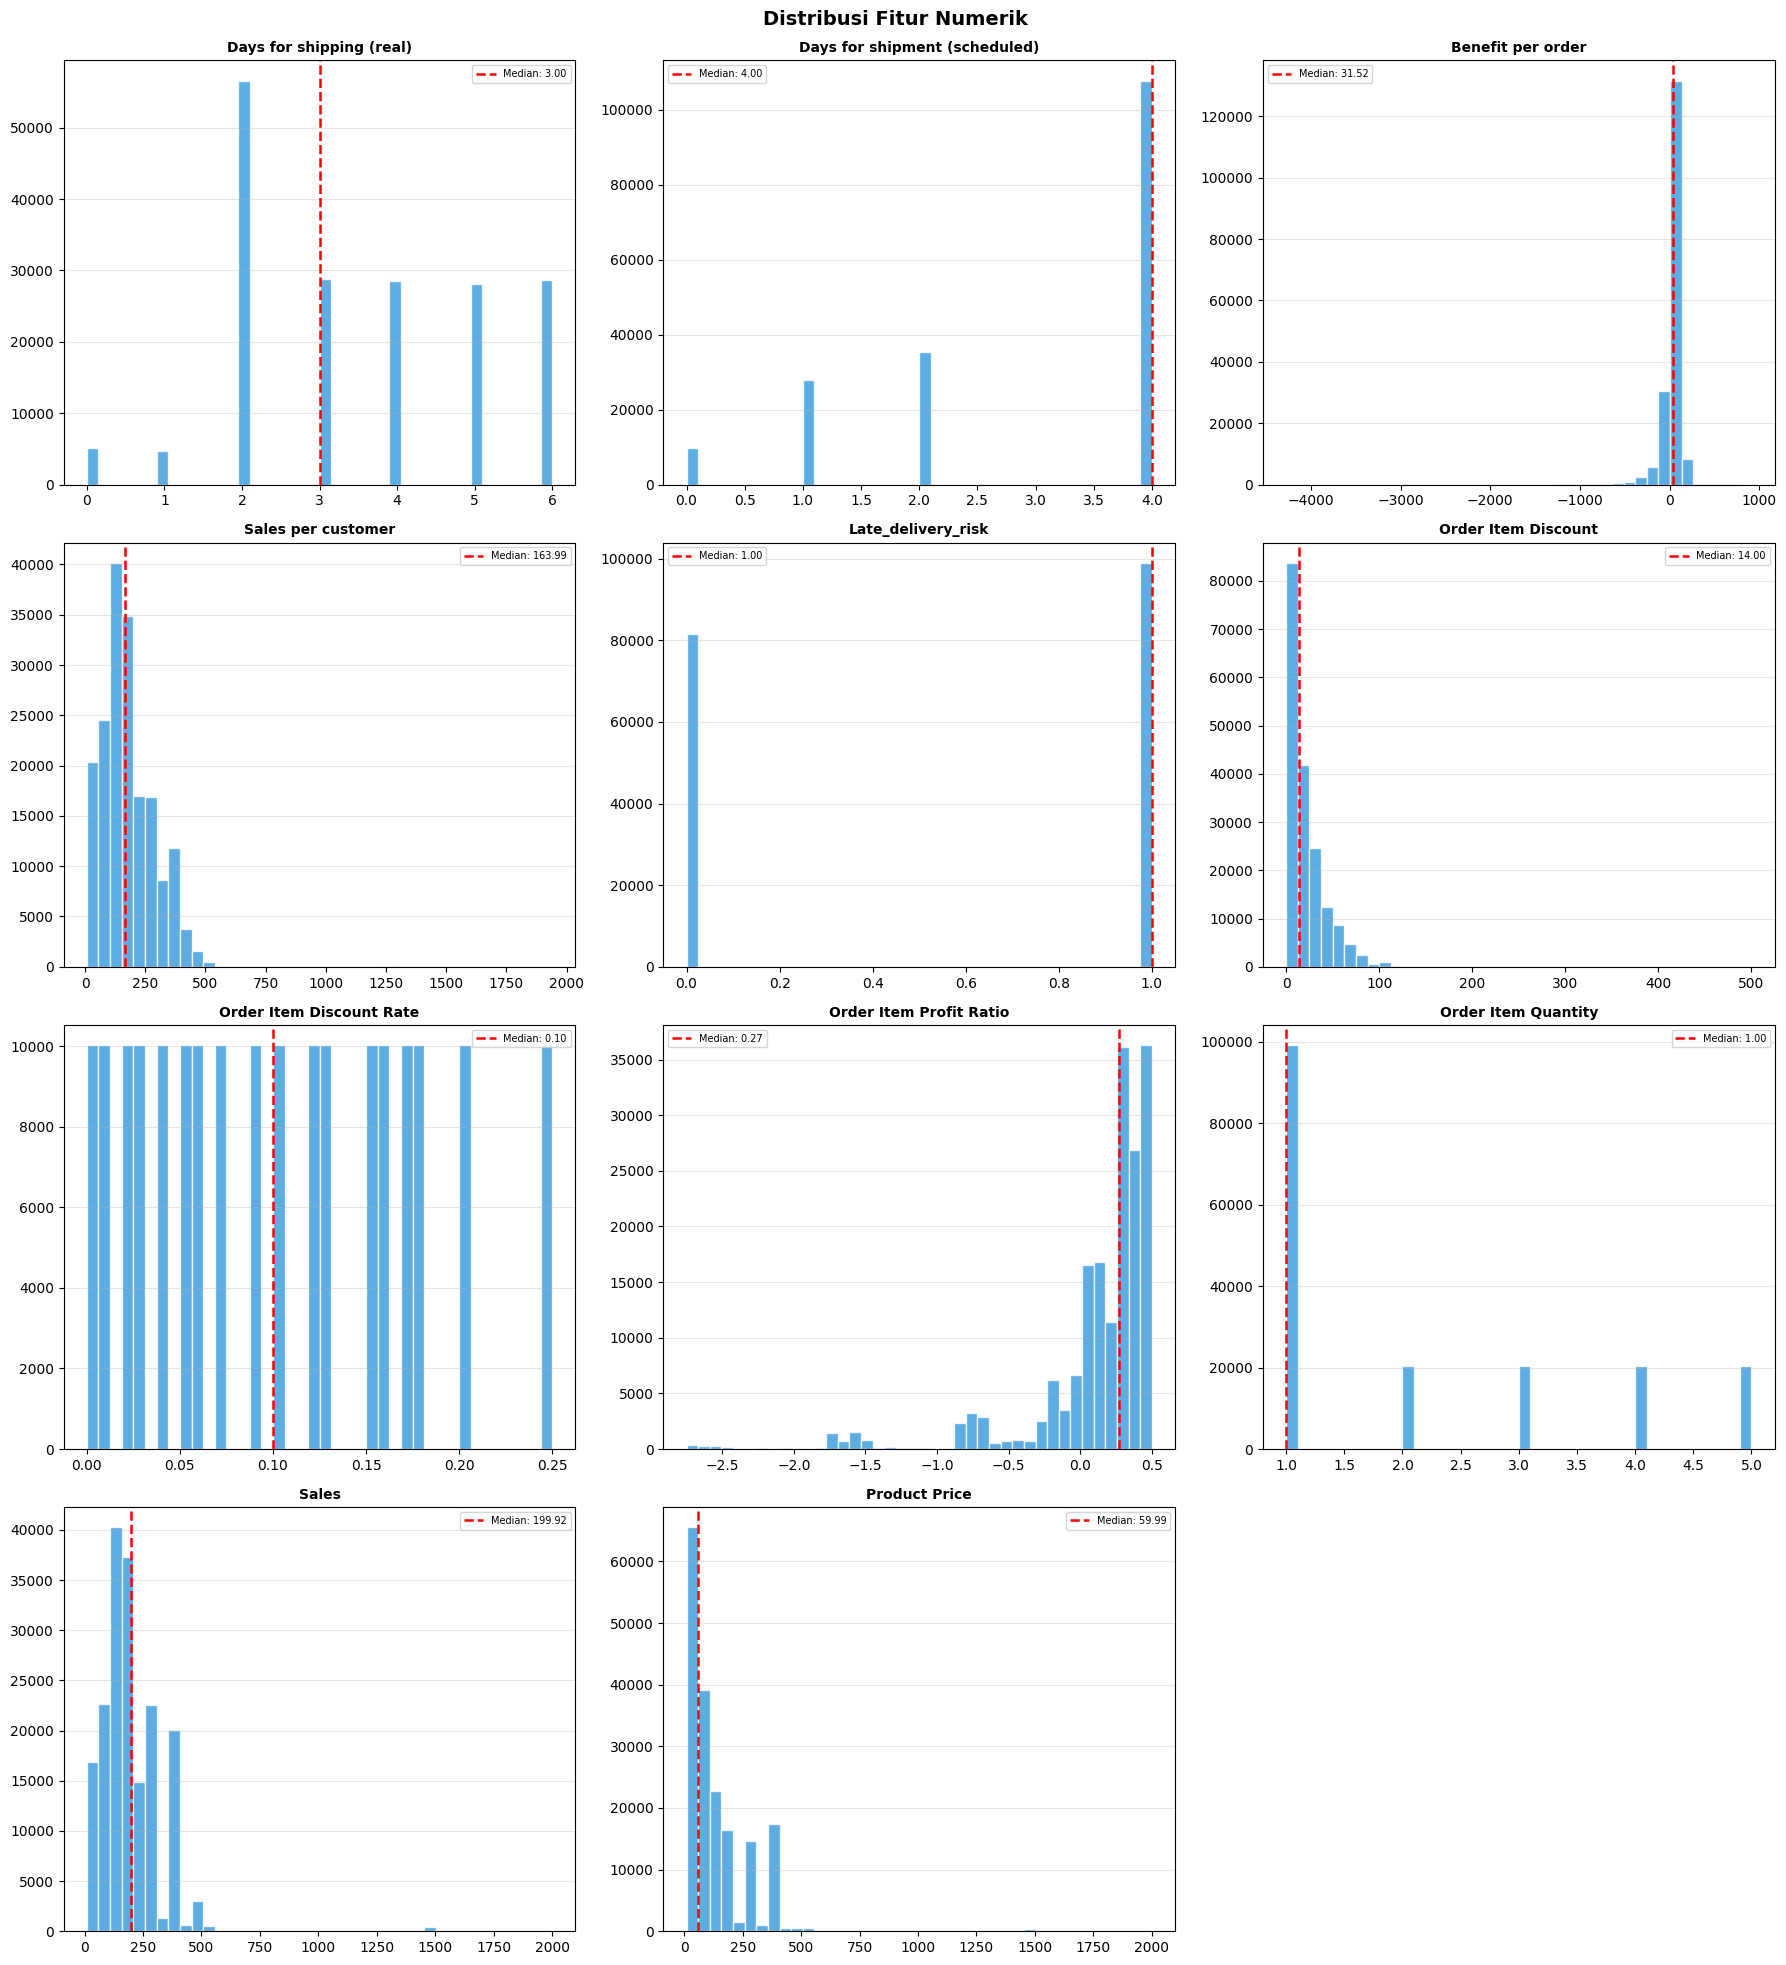


Skewness:
  Days for shipping (real)           :   0.08 → normal
  Days for shipment (scheduled)      :  -0.73 → left-skewed
  Benefit per order                  :  -4.74 → left-skewed
  Sales per customer                 :   2.89 → right-skewed
  Late_delivery_risk                 :  -0.19 → normal
  Order Item Discount                :   3.04 → right-skewed
  Order Item Discount Rate           :   0.34 → normal
  Order Item Profit Ratio            :  -2.89 → left-skewed
  Order Item Quantity                :   0.88 → right-skewed
  Sales                              :   2.88 → right-skewed
  Product Price                      :   3.19 → right-skewed


In [3]:
df_num = df.select_dtypes(include=['float64','int64'])
n_cols = 3
n_rows = (len(df_num.columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()
for i, col in enumerate(df_num.columns):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].median(), color='red', linewidth=1.8, linestyle='--',
               label=f'Median: {df[col].median():.2f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
for j in range(len(df_num.columns), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik\n', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Skewness
print("\nSkewness:")
for col in df_num.columns:
    sk = df[col].skew()
    arah = 'right-skewed' if sk > 0.5 else 'left-skewed' if sk < -0.5 else 'normal'
    print(f"  {col:<35}: {sk:>6.2f} → {arah}")


# Distribusi Fitur Kategorik

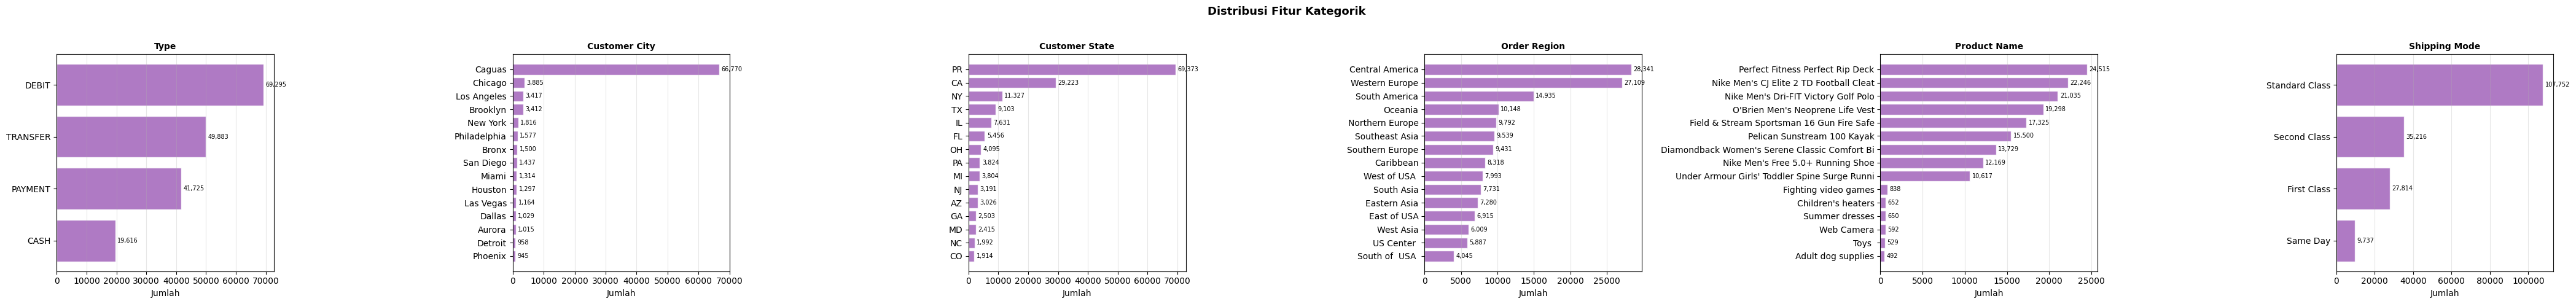

In [4]:
df_cat = df.select_dtypes(include='object')
n_cat  = len(df_cat.columns)
fig, axes = plt.subplots(1, n_cat, figsize=(7*n_cat, 5))
if n_cat == 1: axes = [axes]

for ax, col in zip(axes, df_cat.columns):
    vc = df[col].value_counts().head(15)
    bars = ax.barh(vc.index[::-1], vc.values[::-1], color='#9b59b6', alpha=0.8, edgecolor='white')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Jumlah')
    ax.grid(axis='x', alpha=0.3)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(vc)*0.01, bar.get_y() + bar.get_height()/2,
                f'{int(w):,}', va='center', fontsize=7)
plt.suptitle('Distribusi Fitur Kategorik\n', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# Distribusi Fitur Numerik vs Target

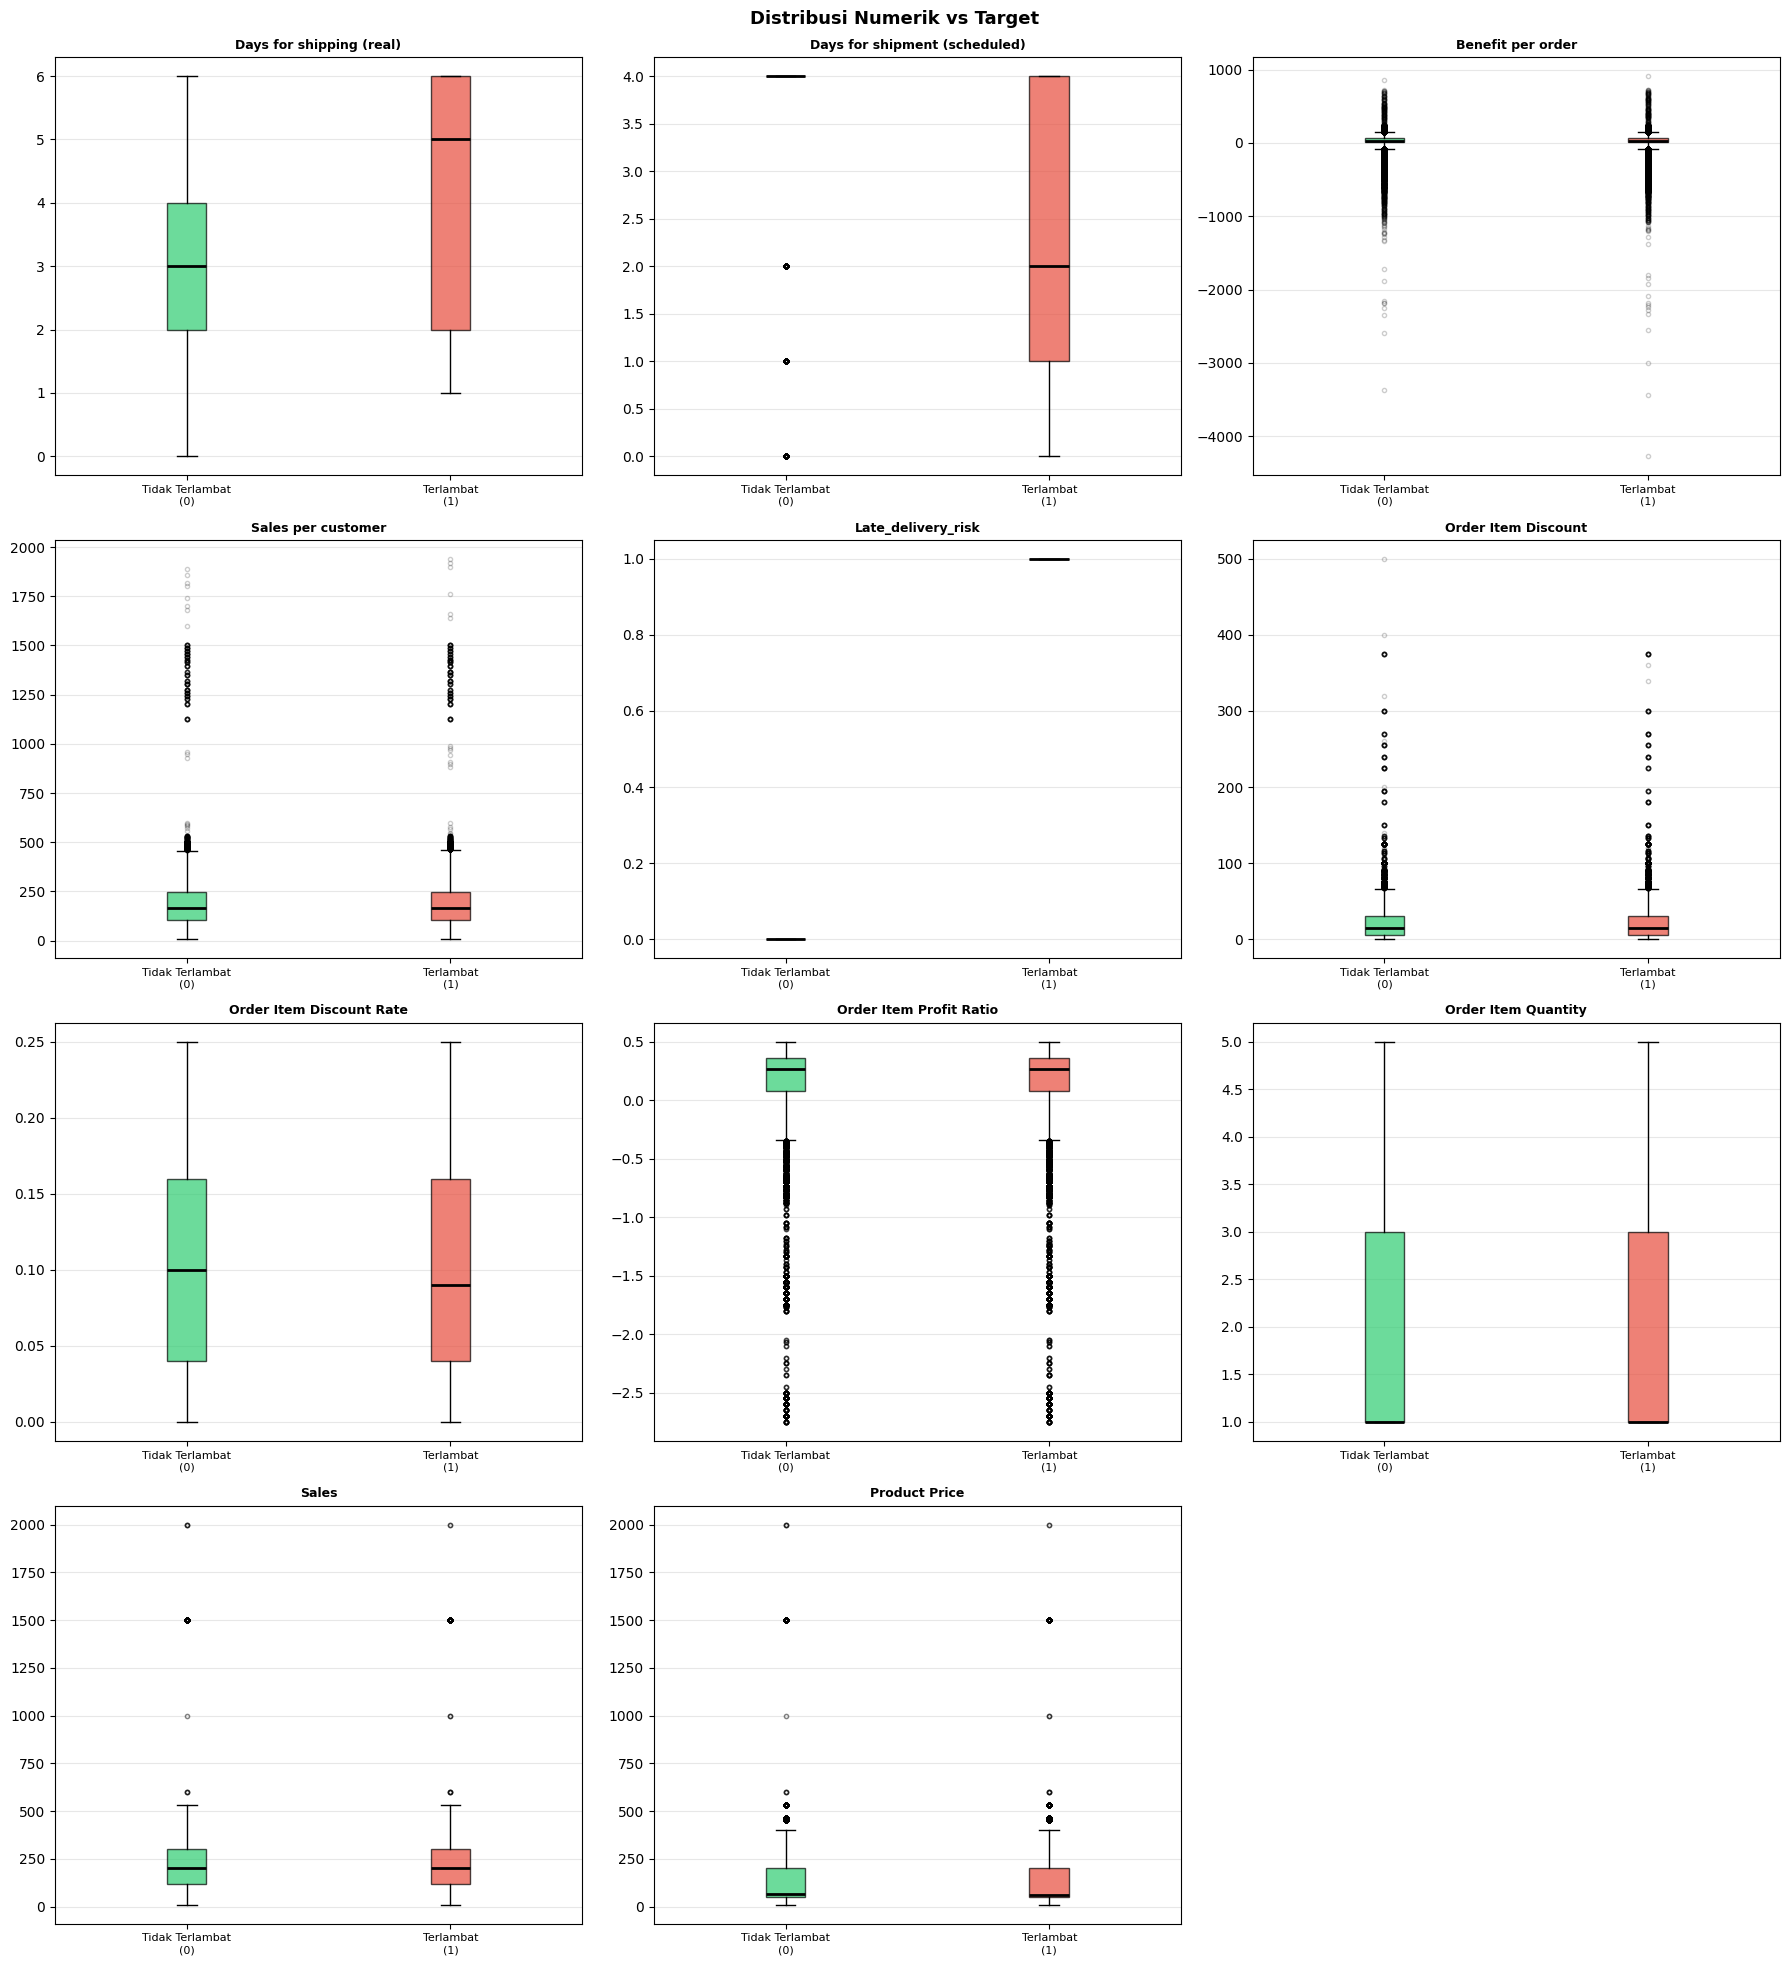


Perbedaan Mean antar Kelas:
  Fitur                                  Mean(0)    Mean(1)    Selisih
  ------------------------------------------------------------
  Days for shipping (real)                 2.780      4.089     +1.310
  Days for shipment (scheduled)            3.491      2.471     -1.020
  Benefit per order                       22.404     21.622     -0.782
  Sales per customer                     183.609    182.695     -0.915
  Late_delivery_risk                       0.000      1.000     +1.000
  Order Item Discount                     20.683     20.650     -0.033
  Order Item Discount Rate                 0.102      0.102     +0.000
  Order Item Profit Ratio                  0.122      0.120     -0.002
  Order Item Quantity                      2.128      2.127     -0.000
  Sales                                  204.292    203.344     -0.947
  Product Price                          141.567    140.957     -0.611


In [6]:
df_num = df.select_dtypes(include=['float64','int64'])
n_cols = 3
n_rows = (len(df_num.columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()
colors = {0: '#2ecc71', 1: '#e74c3c'}

for i, col in enumerate(df_num.columns):
    ax = axes[i]
    data_groups = [df[df[target]==cls][col].dropna() for cls in [0,1]]
    bp = ax.boxplot(data_groups, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', alpha=0.2))
    for patch, cls in zip(bp['boxes'], [0,1]):
        patch.set_facecolor(colors[cls]); patch.set_alpha(0.7)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xticks([1,2])
    ax.set_xticklabels(['Tidak Terlambat\n(0)', 'Terlambat\n(1)'], fontsize=8)
    ax.grid(axis='y', alpha=0.3)
for j in range(len(df_num.columns), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Numerik vs Target\n', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Perbedaan mean
print("\nPerbedaan Mean antar Kelas:")
print(f"  {'Fitur':<35} {'Mean(0)':>10} {'Mean(1)':>10} {'Selisih':>10}")
print('  ' + '-'*60)
for col in df_num.columns:
    m0 = df[df[target]==0][col].mean()
    m1 = df[df[target]==1][col].mean()
    print(f"  {col:<35} {m0:>10.3f} {m1:>10.3f} {m1-m0:>+10.3f}")


# Distribusi Fitur Kategorik vs Target

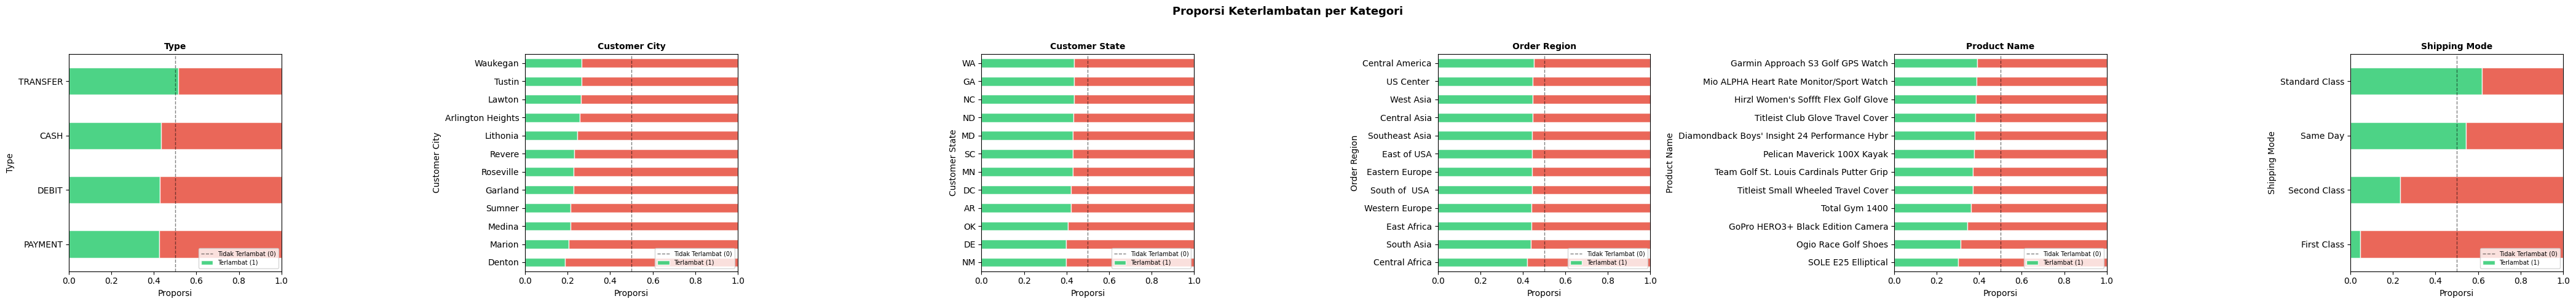


Late Rate Tertinggi per Fitur Kategorik:
  Type                     : PAYMENT                        → 57.5% terlambat
  Customer City            : Denton                         → 81.3% terlambat
  Customer State           : NM                             → 60.3% terlambat
  Order Region             : Central Africa                 → 58.0% terlambat
  Product Name             : SOLE E25 Elliptical            → 70.0% terlambat
  Shipping Mode            : First Class                    → 95.3% terlambat


In [8]:
df_cat = df.select_dtypes(include='object')
n_cat  = len(df_cat.columns)
fig, axes = plt.subplots(1, n_cat, figsize=(7*n_cat, 5))
if n_cat == 1: axes = [axes]

for ax, col in zip(axes, df_cat.columns):
    ct = df.groupby(col)[target].value_counts(normalize=True).unstack(fill_value=0)
    ct = ct.sort_values(1, ascending=False).head(12)
    ct[[0,1]].plot(kind='barh', stacked=True, ax=ax,
                   color=['#2ecc71','#e74c3c'], alpha=0.85, edgecolor='white')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Proporsi'); ax.set_xlim(0,1)
    ax.axvline(0.5, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.legend(['Tidak Terlambat (0)','Terlambat (1)'], fontsize=7, loc='lower right')
plt.suptitle('Proporsi Keterlambatan per Kategori\n', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nLate Rate Tertinggi per Fitur Kategorik:")
for col in df_cat.columns:
    lr  = df.groupby(col)[target].mean().sort_values(ascending=False)
    top = lr.head(1)
    print(f"  {col:<25}: {top.index[0]:<30} → {top.values[0]*100:.1f}% terlambat")
